# Check Called Inversions
Here, we visualize the inversions that were identified for the 20X-medium treatment

In [1]:
library(ggplot2)
library(RJSplot)

## Pooled Inversion Detection
Let's first try the simple option and view the population-called inversions. For that we need the output file (`inversions.bedpe`) and the groundtruth inversions, in other words, the list of inversions we actually simulated and their start/end positions on a contig. We'll do a bit of formatting so we only keep the `sample` name, `contig`, `position_start`, and `position_end`

In [2]:
called_inversion <- read.table("simulated_data/called_sv/leviathan/medium/20X/by_pop/inversions.bedpe", header = T)
called_inversion <- called_inversion[,c("population","contig", "position_start", "position_end")]
names(called_inversion)[1] <- "sample"
called_inversion$sample <- "Pooled-20X-Medium"
tables_rjs(called_inversion, jupyter = TRUE)

Next, we need the actual inversions, which were given as a VCF file to `simuG` (via `Harpy`). It will need a bit for formatting to make it BED-like.

In [3]:
groundtruth_file <- "simulated_data/inversions/medium/inv.medium.vcf"
true_inversions <- read.table(groundtruth_file, header = F)[,c(1,2,8)]
true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
names(true_inversions) <- c("contig", "position_start", "position_end")
true_inversions$sample <- "simulated_inversions"
tables_rjs(true_inversions, jupyter = TRUE)

Next, we concatenate the two datasets by row into a single table.

In [4]:
pooled_inversions <- rbind(called_inversion, true_inversions)

## Per-Sample Inversion Detection
Same idea, except we'll have several more samples on the Y axis. We need to load in the `inversions.bedpe` aggregate file Harpy produces. It might make sense to include the pooled-sample as a sample too. This would give a pretty direct comparison.

In [6]:
all_inversions <- rbind(
    read.table("simulated_data/called_sv/leviathan/medium/20X/by_sample/inversions.bedpe", header = T)[,1:4],
    pooled_inversions
)
tables_rjs(all_inversions, jupyter = TRUE)

Now we plot them, presumably faceted by:
- row -> `contig`
- y-axis -> `sample`

This should be a `geom_segment` with `x` and `xend` corresponding to `position_start` and `position_end`

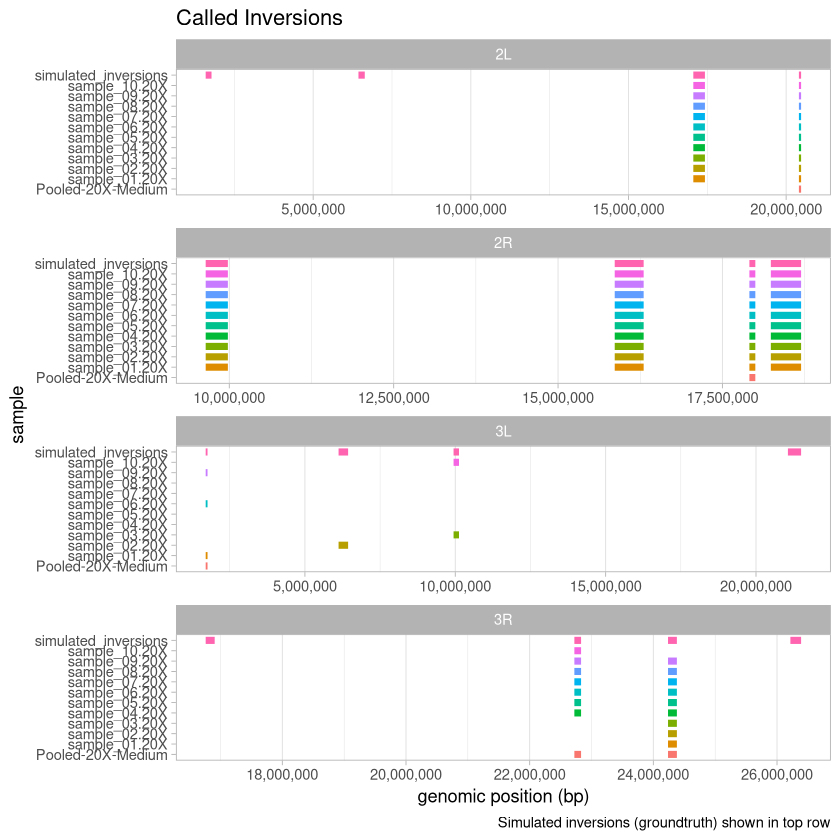

In [92]:
ggplot(
    all_inversions,
    aes(
        x = position_start,
        xend = position_end,
        y = sample,
        yend = sample,
        color = sample
    )
) +
    scale_x_continuous(labels = scales::comma) +
    labs(title = "Called Inversions", x = "genomic position (bp)", caption = "Simulated inversions (groundtruth) shown in top row") + 
    geom_segment(linewidth = 2) +
    facet_wrap(~contig, ncol = 1, scales = "free_x") +
    theme_light() +
    theme(panel.grid.major.y = element_blank(), legend.position = "None")